# Stochastic convolutional networks


<div class="note"><span class="note-t">TL;DR</span>
<p>We train a shared stochastic kernel to classify 4x4 bars-and-stripes images: <code>param_map</code> ties 60 physical gates to 5 logits, and <code>param_shift_inf</code> supplies sample-based gradients. We check one shared-logit gradient against a finite-difference probe, and training reaches 100% held-out accuracy.</p>
</div>

In this tutorial, we build a stochastic convolution layer: a small probabilistic kernel that slides across a $4\times4$ bars-and-stripes image. It plays the same role as a CNN filter, with gates that fire randomly in place of a fixed dot product.

Each image has 16 **probabilistic bits** (pbits), one per pixel, and the layer is a parametrised stochastic circuit over those pbits. Its defining property is weight sharing: the same local kernel is reused at every horizontal pixel pair.

Two `PCNOT` pooling stages then funnel the state into a small set of readout sites. Because we reuse the same horizontal-pair kernel across columns, the layer applies a convolution-like stencil with horizontal weight sharing.

This tutorial uses Torx, JAX, Equinox, Optax, NumPy, and Matplotlib. It assumes basic familiarity with binary classifiers and gradients.

By the end, you'll be able to:

- build one shared four-gate kernel (`PJUMP`, `PReset`, `PNOT`, `PJUMP`) and tie all 60 gate positions to 5 logits with `param_map`,
- train those logits end to end with a sample-based parameter-shift gradient and the Adam optimizer, and
- check that gradient against a finite-difference probe, so you can trust the differentiable path through the sampler.



## Setup

We start with path handling, NumPy, and the notebook helpers that style and save figures consistently.

In [1]:
from pathlib import Path
import sys

import numpy as np



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from jax.scipy.special import logit
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_schematics as P_sch
import _plots_training as P_train

FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()


savefig = make_savefig(FIGURE_DIR)

These imports support circuit construction, optimization, and the fixed data split.

In [4]:
import itertools

import equinox as eqx
import jax
import jax.numpy as jnp
import optax



In [5]:
from torx.psc import (
    DiscretePCircuit,
    PCNOT,
    PJUMP,
    PNOT,
    PReset,
    BranchingSimulator,
)

SEED = 123
rng = np.random.default_rng(SEED)

## The dataset

Bars-and-stripes is a small binary image set whose two classes differ only in whether rows or columns are constant.

Each image either has constant rows (bars: every row is uniform, so the image is horizontal bands) or constant columns (stripes: every column is uniform, so the image is vertical stripes). The all-zero and all-one images belong to both families; this helper keeps those duplicates as bars by convention, yielding 16 bars and 14 stripes. We split the 30 distinct patterns into 24 training examples and 6 test examples.

The `bars_and_stripes` function below builds the labeled image set by enumerating every constant-row pattern (bars) and every constant-column pattern (stripes).

In [6]:
def bars_and_stripes(n):
    patterns, labels = [], []
    # Keep uniform duplicates as bars.
    seen = set()
    for rows in itertools.product([0, 1], repeat=n):
        # Bars: constant rows (repeat one column vector across all columns).
        image = np.repeat(np.array(rows)[:, None], n, axis=1)
        key = tuple(image.reshape(-1))
        if key not in seen:
            patterns.append(image.reshape(-1))
            labels.append(0)
            seen.add(key)
    for cols in itertools.product([0, 1], repeat=n):
        # Stripes: constant columns (repeat one row vector across all rows).
        image = np.repeat(np.array(cols)[None, :], n, axis=0)
        key = tuple(image.reshape(-1))
        if key not in seen:
            patterns.append(image.reshape(-1))
            labels.append(1)
            seen.add(key)
    return np.asarray(patterns, dtype=np.int32), np.asarray(labels, dtype=np.float32)

Set `N_SIDE` and materialize the `patterns` and `labels` arrays.

In [7]:
N_SIDE = 4
N_PBITS = N_SIDE * N_SIDE
patterns, labels = bars_and_stripes(N_SIDE)

Before training, check that `patterns`, `labels`, and `N_PBITS` describe the expected 30 images.

In [8]:
n_bars = int((labels == 0).sum())
n_stripes = int((labels == 1).sum())

assert len(patterns) == 30, f"expected 30 patterns, got {len(patterns)}"
assert patterns.shape[1] == N_PBITS
assert (n_bars, n_stripes) == (16, 14)
assert n_bars + n_stripes == 30

print(f"dataset: {len(patterns)} patterns  ({n_bars} bars, {n_stripes} stripes)")

dataset: 30 patterns  (16 bars, 14 stripes)


## Building the kernel circuit

The local kernel applies four gates to each adjacent horizontal pixel pair: `PJUMP`, `PReset`, `PNOT`, and `PJUMP`.

The two `PJUMP` gates in the four-gate kernel share logit 0, so the kernel uses 3 logits. Across 12 horizontal-pair applications, `param_map` reuses those same 3 logits, the stochastic analogue of weight tying in a CNN. This gives horizontal weight sharing (a convolution-like stencil) without an exact shift symmetry; there is no vertical shared kernel.

Column-then-row `PCNOT` pooling reduces 16 pbits to 4 readout sites, adding two more shared logits.

Each gate is a convex combination (a probability-weighted blend) of the identity and a deterministic operation $B$, applied with probability $\sigma(\theta)$:

$$G(\theta)=\underbrace{(1-\sigma(\theta))\,I}_{\vphantom{\big|}\text{do nothing}}+\underbrace{\sigma(\theta)\,B}_{\vphantom{\big|}\text{apply }B}.$$

The mixing weight is the logistic $\sigma(\theta)=1/(1+e^{-\theta})$, the gate-on probability. All told, the 4 kernel gates use 3 logits, the two pooling stages use 2 more, and 60 physical gates run on 5 trainable logits.

When we pick the initial gate-on probabilities below, `jax.scipy.special.logit` (the inverse sigmoid) converts them to logits.

The `build_scnn_circuit` function lays out the shared kernel and the two pooling stages.

In [9]:
def build_scnn_circuit():
    """Construct the shared-kernel SCNN circuit, parameter map, and readout sites."""
    gates = []
    param_map = []
    # Shared local stochastic convolution on adjacent horizontal pairs.
    for r in range(N_SIDE):
        for c in range(N_SIDE - 1):
            i = r * N_SIDE + c
            j = i + 1
            gates.extend(
                [
                    PJUMP([i, j]),
                    PReset(j),
                    PNOT(j),
                    PJUMP([j, i]),
                ]
            )
            # These four physical gates read from three shared kernel logits.
            param_map.extend([0, 1, 2, 0])
    # Pool adjacent columns, then adjacent rows of the pooled sites.
    pooled = []
    for r in range(N_SIDE):
        for c in range(0, N_SIDE, 2):
            src = r * N_SIDE + c
            sink = src + 1
            gates.append(PCNOT([src, sink]))
            param_map.append(3)
            pooled.append(sink)
    readout_sites = []
    for c in range(2):
        for r in range(0, N_SIDE, 2):
            src = pooled[r * 2 + c]
            sink = pooled[(r + 1) * 2 + c]
            gates.append(PCNOT([src, sink]))
            param_map.append(4)
            readout_sites.append(sink)
    return DiscretePCircuit(gates), np.asarray(param_map), readout_sites

Create `circuit`, `param_map`, and `readout_sites`, then choose the five initial shared logits.

In [10]:
circuit, param_map, readout_sites = build_scnn_circuit()
initial_gate_logits = jnp.asarray(
    [logit(0.34), logit(0.08), logit(0.06), logit(0.55), logit(0.60)]
)

Check the gate count, `readout_sites`, and number of shared logits before plotting.

In [11]:
assert len(circuit.gates) == 60, f"expected 60 gates, got {len(circuit.gates)}"
assert len(readout_sites) == 4
assert len(np.unique(param_map)) == 5

print(f"circuit: {len(circuit.gates)} gates, {len(np.unique(param_map))} shared logits")
print(f"readout sites: {readout_sites}")

circuit: 60 gates, 5 shared logits
readout sites: [5, 13, 7, 15]


This figure shows the four-gate stochastic kernel applied to one adjacent pixel pair. Orange marks the two-site `PJUMP` coupling gates, and slate marks the single-site gates, `PReset` and `PNOT`.

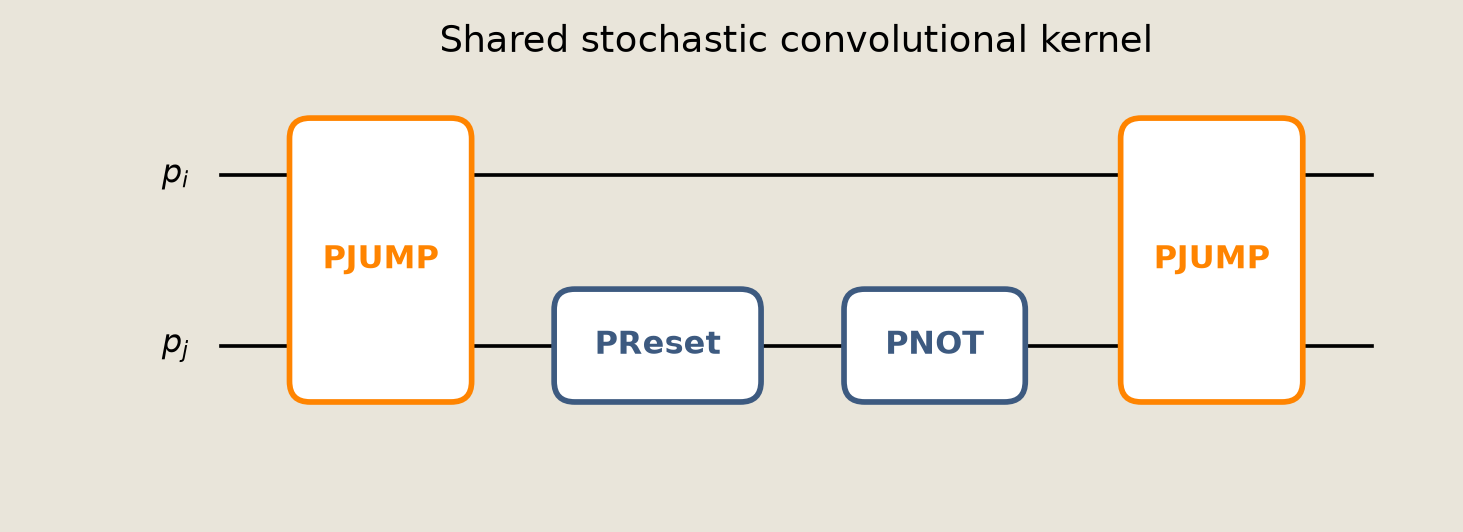

In [12]:
kernel = DiscretePCircuit(circuit.gates[:4])
fig = P_sch.plot_kernel_circuit(kernel)
savefig(fig, "08_scnn_circuit")

The weight-sharing schematic shows where the five logits appear in the full `circuit`. The next cells recover the spatial wiring from `circuit` and `param_map`, then draw it.

The 16 pbits are laid out on the $4\times4$ grid. Each horizontal pair receives the same local kernel, and the two-stage `PCNOT` pooling funnels the state into 4 readout sites. Gold and copper distinguish the two `PCNOT` pooling stages.

In [13]:
# Recover the spatial wiring from the circuit + param_map for the schematic.
def _gate_sites(g):
    return [int(v) for v in g.sites]




In [14]:
conv_pairs, _seen = [], set()
col_pool_edges, row_pool_edges = [], []
for g, p in zip(circuit.gates, param_map):
    if p not in (0, 3, 4):
        continue
    s = _gate_sites(g)
    if p == 0 and len(s) == 2:  # PJUMP conv gate -> horizontal pixel pair
        pair = tuple(sorted(s))
        if pair not in _seen:
            _seen.add(pair)
            conv_pairs.append(pair)
    elif p == 3:  # stage-1 column pooling PCNOT
        col_pool_edges.append((s[0], s[1]))
    elif p == 4:  # stage-2 row pooling PCNOT
        row_pool_edges.append((s[0], s[1]))



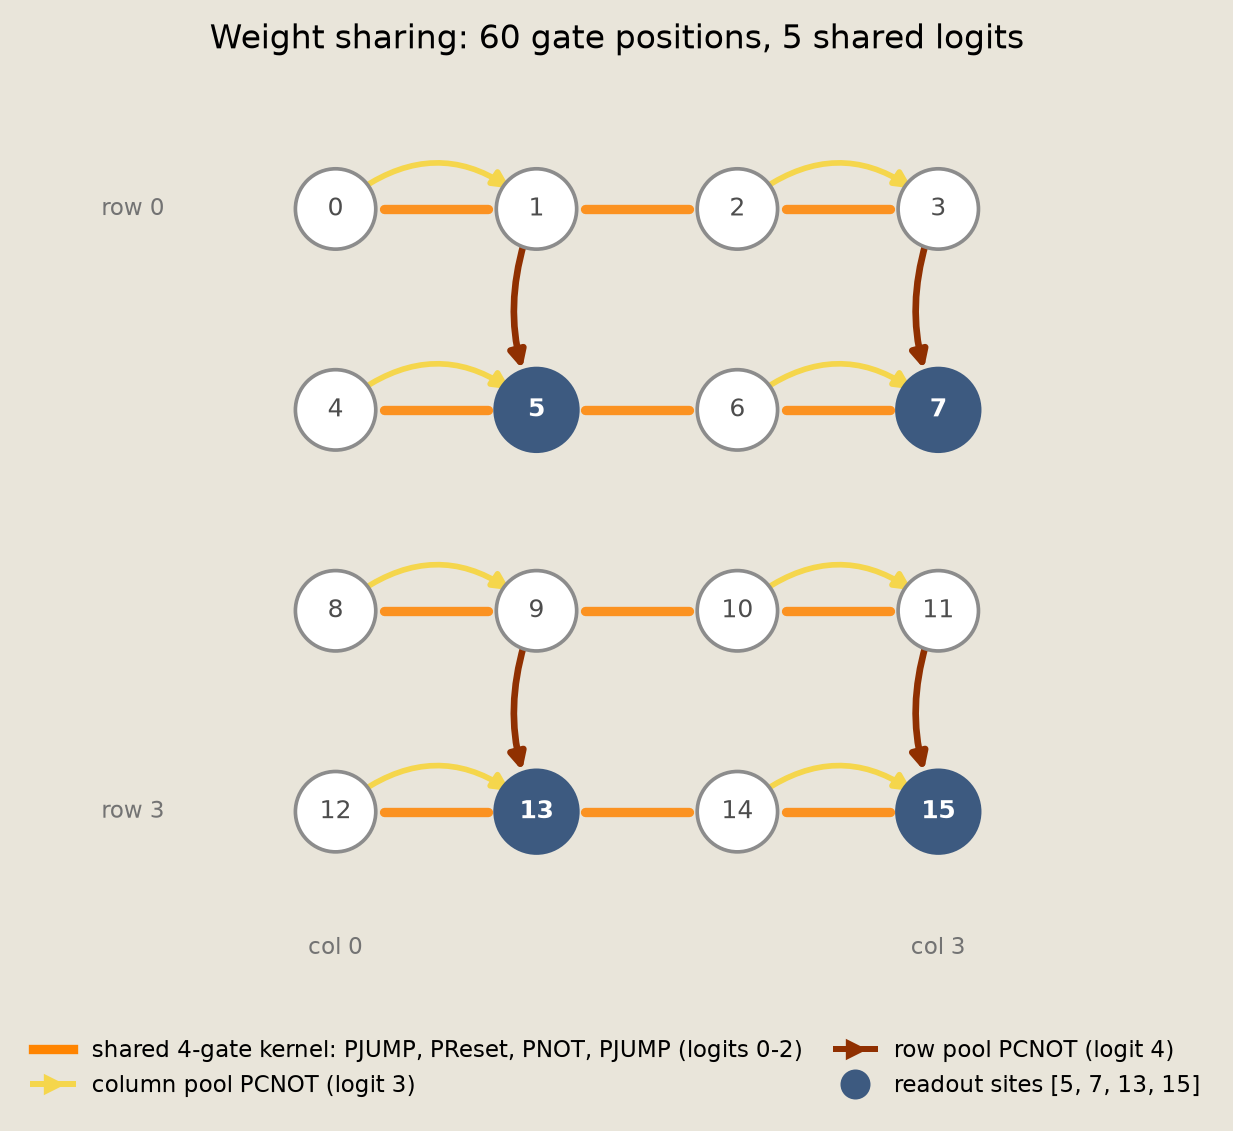

In [15]:
fig = P_sch.plot_weight_sharing_schematic(
    N_SIDE,
    conv_pairs,
    col_pool_edges,
    row_pool_edges,
    readout_sites,
    len(circuit.gates),
    len(np.unique(param_map)),
)
savefig(fig, "08_weight_sharing")

Only the five shaded gate types are free parameters; every other gate position is a tied copy of one of them.

## Training the kernel

To train through the sampler, we need a derivative that works with samples.

`BranchingSimulator` with `diff_method="param_shift_inf"` and `num_samples=256` gives differentiable expected readouts. For a gate $G(\theta)=(1-\sigma(\theta))I+\sigma(\theta)B$, the method evaluates the branches by clamping the gate logit to $-\infty$ and $+\infty$. Those limits force the identity branch and the $B$ branch deterministically.

For a readout $O$, the derivative of the expected readout with respect to the gate logit is

$$
\frac{\mathrm{d}}{\mathrm{d}\theta}\,\mathbb E[O]\;=\;\sigma(\theta)\,\bigl(\mathbb E[O\mid B]-\mathbb E[O]\bigr),
$$

where the $\pm\infty$ clamps supply the branch expectations $\mathbb E[O\mid I]$ and $\mathbb E[O\mid B]$, and $\mathbb E[O]=(1-\sigma(\theta))\,\mathbb E[O\mid I]+\sigma(\theta)\,\mathbb E[O\mid B]$ is the expectation under the current circuit. Each expectation is estimated from samples. Unlike parameter-shift rules that evaluate the circuit at two finite shifted logits, this method evaluates the two deterministic branches directly.

Build the differentiable sampler `sim` and compile the circuit once into `scnn_template`. Each forward pass swaps the shared logits into that template with `eqx.tree_at`, the template-reuse pattern from notebook 07, instead of rebuilding the circuit every call.

In [16]:
sim = BranchingSimulator(diff_method="param_shift_inf", num_samples=256)
# compile the structure-only circuit once; the forward pass swaps in the
# current shared logits with eqx.tree_at instead of rebuilding the circuit.
# num_samples comes from the calling sampler, so this template is reusable by
# the finite-difference sampler too.
scnn_template = sim.build_circuit(circuit, [jnp.zeros((1,)) for _ in circuit.gates])

The `SCNN` module broadcasts the 5 shared logits to all 60 gate positions, reads out 4 sites, and feeds them to a linear sigmoid classifier.

In [17]:
class SCNN(eqx.Module):
    gate_logits: jax.Array
    linear: eqx.nn.Linear
    # non-inexact: adam skips structural indices
    _param_map: jax.Array
    _readout_sites_arr: jax.Array

    def __call__(self, x, key, sampler):
        # Broadcast the 5 shared logits onto the 60 physical gate positions.
        full_thetas = self.gate_logits[self._param_map][:, None]
        # Swap the shared logits into the precompiled template instead of
        # rebuilding the circuit; keeps the thetas tied to the trainable logits.
        compiled = eqx.tree_at(lambda c: c.thetas, scnn_template, full_thetas)
        ev = sampler.expval_all(compiled, x, key)
        # The classifier sees only the pooled readout sites.
        features = ev[self._readout_sites_arr]
        return jax.nn.sigmoid(jnp.squeeze(self.linear(features)))

Use `rng` to split the `patterns` into a fixed train set and test set.

In [18]:
order = rng.permutation(len(patterns))
train_idx, test_idx = order[:24], order[24:]
x_train = jnp.asarray(patterns[train_idx])
y_train = jnp.asarray(labels[train_idx])
x_test = jnp.asarray(patterns[test_idx])
y_test = jnp.asarray(labels[test_idx])
train_n, test_n = len(x_train), len(x_test)
assert train_n == 24 and test_n == 6
test_class_counts = np.bincount(np.asarray(y_test, dtype=np.int32), minlength=2)
test_majority_count = int(test_class_counts.max())
test_majority_acc = test_majority_count / test_n
print(f"train / test split: {train_n} / {test_n}")
print(
    f"test majority baseline: {test_majority_count} of {test_n} "
    f"({test_majority_acc:.0%})"
)

train / test split: 24 / 6
test majority baseline: 4 of 6 (67%)


Initialize the `SCNN` model from the structure-only `circuit` and the shared-logit wiring.

In [19]:
model = SCNN(
    gate_logits=initial_gate_logits,
    linear=eqx.nn.Linear(len(readout_sites), 1, key=jax.random.key(SEED)),
    _param_map=jnp.asarray(param_map),
    _readout_sites_arr=jnp.asarray(readout_sites),
)

`optax.adam` updates only the trainable arrays in the Equinox model.

In [20]:
optimizer = optax.adam(5e-2)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

`bce_loss` computes binary cross-entropy over the batch; `loss_fn` wraps it with `eqx.filter_value_and_grad` to add the parameter-shift gradient.

In [21]:
def bce_loss(model, x_batch, y_batch, key, sampler=sim):
    # Give each image its own random key for independent sampler noise.
    keys = jax.random.split(key, len(x_batch))
    preds = jax.vmap(lambda xi, ki: model(xi, ki, sampler))(x_batch, keys)
    preds = jnp.clip(preds, 1e-6, 1.0 - 1e-6)
    return jnp.mean(
        -(y_batch * jnp.log(preds) + (1.0 - y_batch) * jnp.log(1.0 - preds))
    )


# undecorated bce_loss is reused by the finite-difference probe (loss only);
# this wrapper adds the param-shift gradient for training and the analytic check
loss_fn = eqx.filter_value_and_grad(bce_loss)

`train_step` takes one Adam step: compute the loss and gradients, then apply the updates.

In [22]:
@eqx.filter_jit
def train_step(model, opt_state, x_batch, y_batch, key):
    loss, grads = loss_fn(model, x_batch, y_batch, key)
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_inexact_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

`evaluate` returns held-out loss and accuracy for each epoch.

In [23]:
@eqx.filter_jit
def evaluate(model, x_batch, y_batch, key, sampler=sim):
    keys = jax.random.split(key, len(x_batch))
    preds = jax.vmap(lambda xi, ki: model(xi, ki, sampler))(x_batch, keys)
    preds = jnp.clip(preds, 1e-6, 1.0 - 1e-6)
    loss = jnp.mean(
        -(y_batch * jnp.log(preds) + (1.0 - y_batch) * jnp.log(1.0 - preds))
    )
    acc = jnp.mean((preds >= 0.5) == y_batch)
    return loss, acc

`fit_model` runs 90 full-batch epochs and records the validation trace.

In [24]:
def fit_model(model, opt_state, x_train, y_train, x_test, y_test):
    loss_history, acc_history = [], []
    key = jax.random.key(SEED)
    for epoch in range(90):
        # Split once per epoch so training and validation use independent samples.
        key, train_key, eval_key = jax.random.split(key, 3)
        model, opt_state, _ = train_step(model, opt_state, x_train, y_train, train_key)
        val_loss, val_acc = evaluate(model, x_test, y_test, eval_key)
        # keep device arrays; convert the whole trace to host once after training
        loss_history.append(val_loss)
        acc_history.append(val_acc)
    return model, opt_state, np.asarray(loss_history), np.asarray(acc_history)

Run `fit_model`, then report the final validation loss and accuracy.

In [25]:
model, opt_state, loss_history, acc_history = fit_model(
    model, opt_state, x_train, y_train, x_test, y_test
)

print(f"final val loss:  {loss_history[-1]:.4f}")
print(f"final accuracy:  {acc_history[-1]:.2%}")

final val loss:  0.0945
final accuracy:  100.00%


Training converges: the model reaches 100% held-out accuracy, well above the 67% majority baseline printed at the split.


### Gradient check

As a sanity check on one shared `PJUMP` logit (`LOGIT_IDX = 0`), the `param_shift_inf` gradient should agree with a finite-difference estimate up to Monte Carlo noise, the random scatter from finite sampling. In the next cells, we compute both gradients on one small batch and report the relative error. The check covers only one of the five logits, at 30% tolerance.

Compute the analytic gradient for one shared `PJUMP` logit using a small bars-plus-stripes batch.

In [26]:
LOGIT_IDX = 0
bars_idx = np.where(labels == 0)[0][:4]
stripes_idx = np.where(labels == 1)[0][:4]
batch_x = jnp.asarray(patterns[np.concatenate([bars_idx, stripes_idx])])
batch_y = jnp.asarray(labels[np.concatenate([bars_idx, stripes_idx])])
key_grad = jax.random.key(SEED + 7)

_, grads = loss_fn(model, batch_x, batch_y, key_grad)
g_analytic = float(grads.gate_logits[LOGIT_IDX])

`fd_grad` probes the same logit with a central finite difference, using a fresh `BranchingSimulator` at the requested sample count.

In [27]:
def fd_grad(m, epsilon, n_samples):
    fd_sampler = BranchingSimulator(diff_method="param_shift_inf", num_samples=n_samples)
    m_plus = eqx.tree_at(
        lambda mod: mod.gate_logits,
        m,
        m.gate_logits.at[LOGIT_IDX].add(epsilon),
    )
    m_minus = eqx.tree_at(
        lambda mod: mod.gate_logits,
        m,
        m.gate_logits.at[LOGIT_IDX].add(-epsilon),
    )
    # Reuse key_grad on both sides so only the logit perturbation changes.
    # bce_loss (undecorated) computes loss only, so no param-shift gradient is
    # wasted on each finite-difference evaluation.
    loss_plus = float(bce_loss(m_plus, batch_x, batch_y, key_grad, fd_sampler))
    loss_minus = float(bce_loss(m_minus, batch_x, batch_y, key_grad, fd_sampler))
    return (loss_plus - loss_minus) / (2.0 * epsilon)

Compare the analytic gradient with a finite-difference estimate, retrying with more samples if Monte Carlo noise dominates.

In [28]:
print(f"analytic (param-shift, logit {LOGIT_IDX}): {g_analytic:.6f}")
REL_ERR_TOL = 0.30
FD_PROBES = [(256, 0.05), (1024, 0.05), (2048, 0.10)]
g_fd, rel_err = None, np.inf
for i, (n_samples, eps) in enumerate(FD_PROBES):
    g_fd = fd_grad(model, eps, n_samples)
    rel_err = abs(g_analytic - g_fd) / (abs(g_fd) + 1e-6)
    label = "finite-diff" if i == 0 else "retry finite-diff"
    print(f"{label} (eps={eps}, {n_samples} samples/side): {g_fd:.6f}")
    print(f"relative error: {rel_err:.4f}")
    if rel_err < REL_ERR_TOL:
        break

analytic (param-shift, logit 0): -0.013972
finite-diff (eps=0.05, 256 samples/side): -0.016633
relative error: 0.1600


Assert against the named tolerance used by the probe ladder.

In [29]:
assert (
    rel_err < REL_ERR_TOL
), f"gradient check failed: analytic={g_analytic}, fd={g_fd}, rel_err={rel_err}"
print(f"gradient check passed (rel_err < {REL_ERR_TOL:.2f})")

gradient check passed (rel_err < 0.30)


## Kernel parameter shifts

A nonzero shift shows that the gradient reached the shared kernel. The table lists the initial logit, trained logit, and shift for each shared gate.

In [30]:
gate_names = ["PJUMP", "PReset", "PNOT", "PCNOT-col", "PCNOT-row"]

print(f"{'gate':<12}  {'init logit':>10}  {'trained logit':>13}  {'shift':>8}")
print("-" * 48)
for name, init_l, fin_l in zip(
    gate_names, initial_gate_logits.tolist(), model.gate_logits.tolist()
):
    print(f"{name:<12}  {init_l:>10.4f}  {fin_l:>13.4f}  {fin_l - init_l:>+8.4f}")

gate_shift = float(jnp.linalg.norm(model.gate_logits - initial_gate_logits))
max_abs_shift = float(jnp.max(jnp.abs(model.gate_logits - initial_gate_logits)))

print(f"\nL2 shift: {gate_shift:.4f}    max |shift|: {max_abs_shift:.4f}")

assert acc_history[-1] >= 0.75, f"accuracy {acc_history[-1]:.2%} below 0.75 threshold"
assert gate_shift > 1e-3, "gate logits did not move during training"
assert (
    max_abs_shift > 0.05
), f"max logit shift {max_abs_shift:.4f} < 0.05, gradient did not reach the kernel"
print("\nall checks passed")
print("  acc_history[-1] >= 0.75")
print("  gate logit L2 shift > 1e-3")
print("  max |gate logit shift| > 0.05")

gate          init logit  trained logit     shift
------------------------------------------------
PJUMP            -0.6633         0.1168   +0.7801
PReset           -2.4423        -5.6673   -3.2250
PNOT             -2.7515        -6.2990   -3.5474
PCNOT-col         0.2007         3.6765   +3.4758
PCNOT-row         0.4055        -2.8609   -3.2664



L2 shift: 6.8076    max |shift|: 3.5474

all checks passed
  acc_history[-1] >= 0.75
  gate logit L2 shift > 1e-3
  max |gate logit shift| > 0.05


## Training curve

The training curve summarizes the validation loss, held-out accuracy, and one bars-and-stripes example.

The curves are not monotone. Held-out accuracy starts below the 67% majority baseline and stays jumpy while the validation loss first rises before it starts to fall. Accuracy then climbs as the logits separate, and the final evaluation prints 100%. The `param_shift_inf` estimator is noisy until the logits push the readouts away from 0.5, which explains the slow, jittery start.

The split cell computes the held-out majority-class baseline from `y_test`, so we look for accuracy comfortably above that seed-specific count.

In [31]:
# Pick a visually informative bar pattern: top two rows black, bottom two white.
bar_idx = next(
    i
    for i, (p, l) in enumerate(zip(patterns, labels))
    if l == 0 and tuple(p.reshape(N_SIDE, N_SIDE)[:, 0]) == (1, 1, 0, 0)
)
bar_image = patterns[bar_idx].reshape(N_SIDE, N_SIDE)



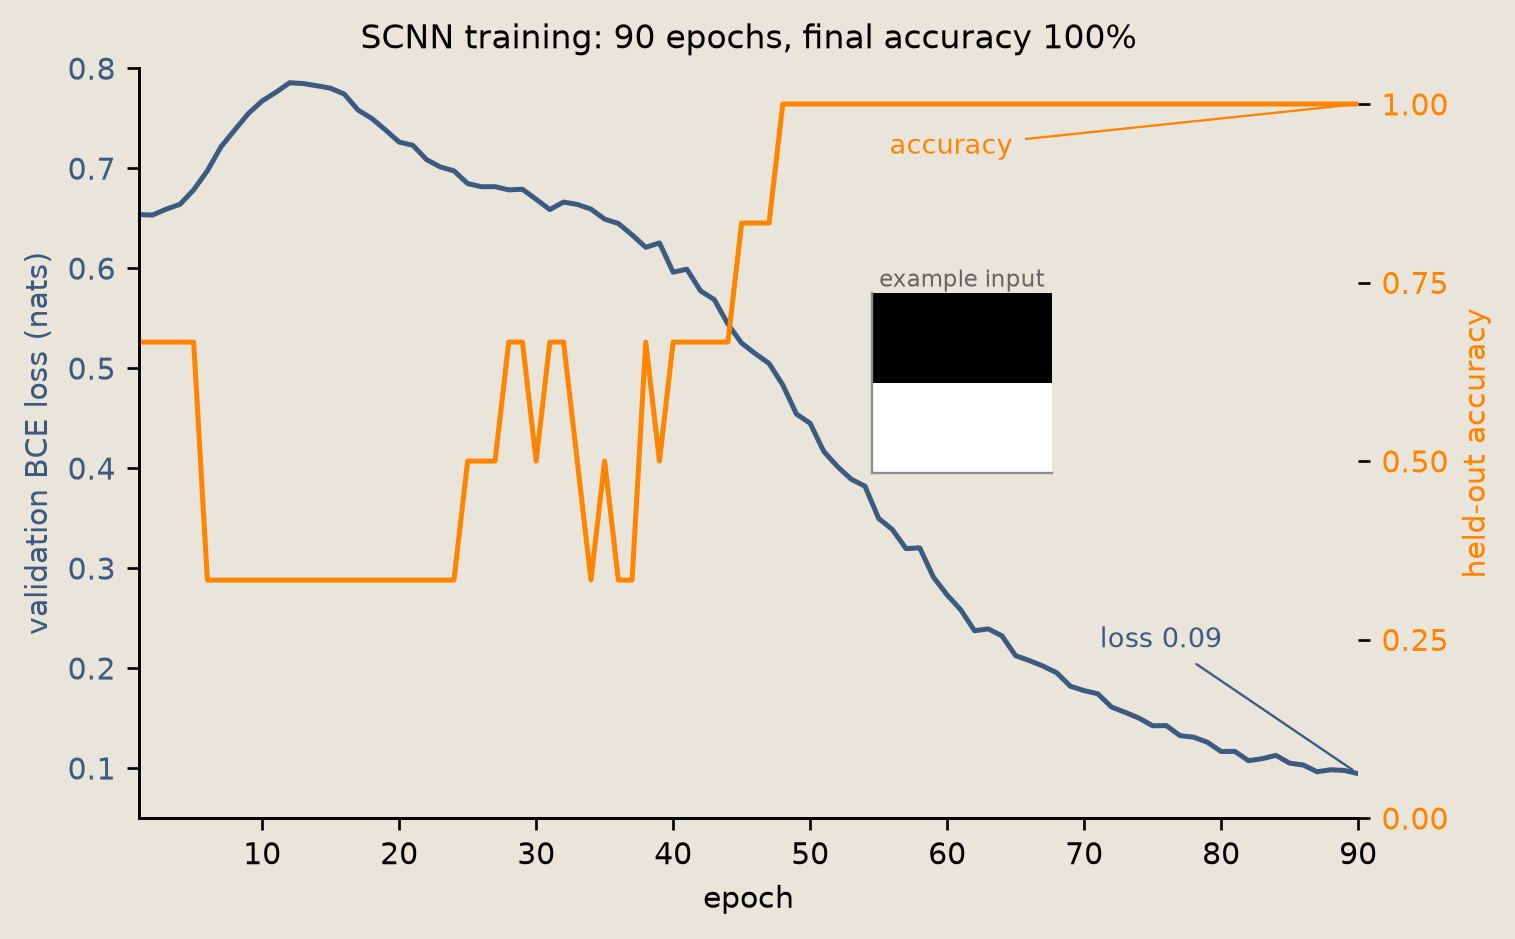

final accuracy:         100.00%
gate logit L2 shift:    6.8076
max |gate logit| shift: 3.5474


In [32]:
fig = P_train.plot_training_curve(
    loss_history,
    acc_history,
    bar_image,
    title=f"SCNN training: 90 epochs, final accuracy {acc_history[-1]:.0%}",
)
savefig(fig, "08_scnn_training")
print(f"final accuracy:         {acc_history[-1]:.2%}")
print(f"gate logit L2 shift:    {gate_shift:.4f}")
print(f"max |gate logit| shift: {max_abs_shift:.4f}")

## Conclusion

You have now built a stochastic convolution layer that classifies bars-and-stripes images by taking gradients through the sampler.

The image uses 16 pbits, one per pixel, and the layer is a stochastic circuit over those pbits.

- A four-gate kernel (`PJUMP`, `PReset`, `PNOT`, `PJUMP`) runs on every horizontal adjacent pixel pair, with `PCNOT` pooling down to 4 readout sites.
- `param_map` ties all 60 physical gates to 5 shared logits, giving a convolution-like horizontal stencil rather than an exact shift symmetry.
- `param_shift_inf` returns a sample-based gradient through the sampler, and `optax.adam` trains the shared logits and a linear head together.
- A finite-difference probe sanity-checks one shared `PJUMP` logit against the `param_shift_inf` gradient (one logit, one small batch, 30% tolerance), which gives evidence that the sampler path is differentiable while stopping short of a full multi-logit verification.

[`09_stochastic_graph_networks.ipynb`](09_stochastic_graph_networks.ipynb) shows another stochastic-circuit learning pattern with shared parameters.

## References

1. Mitarai, K., Negoro, M., Kitagawa, M., Fujii, K. 2018. [*Quantum circuit learning*](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.032309). Phys. Rev. A 98, 032309.
2. Schuld, M., Bergholm, V., Gogolin, C., Izaac, J., Killoran, N. 2019. [*Evaluating analytic gradients on quantum hardware*](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.99.032331). Phys. Rev. A 99, 032331.

